Load Google Speech Commands v0.02 via HuggingFace, confirm 105,829 clips at 16 kHz,
verify the 10-command + unknown + silence class split. Report class distribution (some commands may have
slightly more examples). Listen to 10 samples per class to verify audio quality.

In [31]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torchaudio
import torchcodec
from torchaudio.datasets import SPEECHCOMMANDS
from IPython.display import Audio, display

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DATA_ROOT = "./data"

In [5]:
train_set = SPEECHCOMMANDS(DATA_ROOT, download=False, subset="training")
val_set = SPEECHCOMMANDS(DATA_ROOT, download=False, subset="validation")
test_set = SPEECHCOMMANDS(DATA_ROOT, download=False, subset="testing")

print(f"Train: {len(train_set)} \nVal: {len(val_set)} \nTest: {len(test_set)}")
print(f"Total: {len(train_set) + len(val_set)+len(test_set)}")

Train: 84843 
Val: 9981 
Test: 11005
Total: 105829


##### Inspecting first example tuple structure

In [3]:
waveform, sample_rate, label, speaker_id, utterance_number = train_set[0]

print(f"Waveform shape: {waveform.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Label: '{label}'")
print(f"Speaker ID: '{speaker_id}'")
print(f"Utterance Number: {utterance_number}")
print(f"Duration: {waveform.shape[1] / sample_rate:.3f}s")


Waveform shape: torch.Size([1, 16000])
Sample rate: 16000 Hz
Label: 'backward'
Speaker ID: '0165e0e8'
Utterance Number: 0
Duration: 1.000s


##### all are 16 kHz

In [12]:
df = pd.DataFrame([train_set[i][1] for i in range(10)], columns=["sample_rate"])
df.describe()

,sample_rate
count,10.0
mean,16000.0
std,0.0
min,16000.0
25%,16000.0
50%,16000.0
75%,16000.0
max,16000.0


##### Looks like we have far more labels than we initially stated:
['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']

In [19]:
labels_df = pd.DataFrame([train_set[i][2] for i in range(len(train_set))], columns=["label"])

unique_labels = set(labels_df["label"])

print(sorted(unique_labels))


['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [20]:
expected_labels = ["yes", "no", "up", "down", "left", "right",
               "on", "off", "stop", "go", "unknown", "silence"]

for i in CLASS_ORDER:
    x = i in (unique_labels)
    print(f"{i}: {x}")

yes: True
no: True
up: True
down: True
left: True
right: True
on: True
off: True
stop: True
go: True
unknown: False
silence: False


In [24]:
value_counts = pd.DataFrame(labels_df.value_counts()).reset_index()
value_counts.head()

,label,count
0,zero,3250
1,five,3240
2,yes,3228
3,seven,3205
4,nine,3170


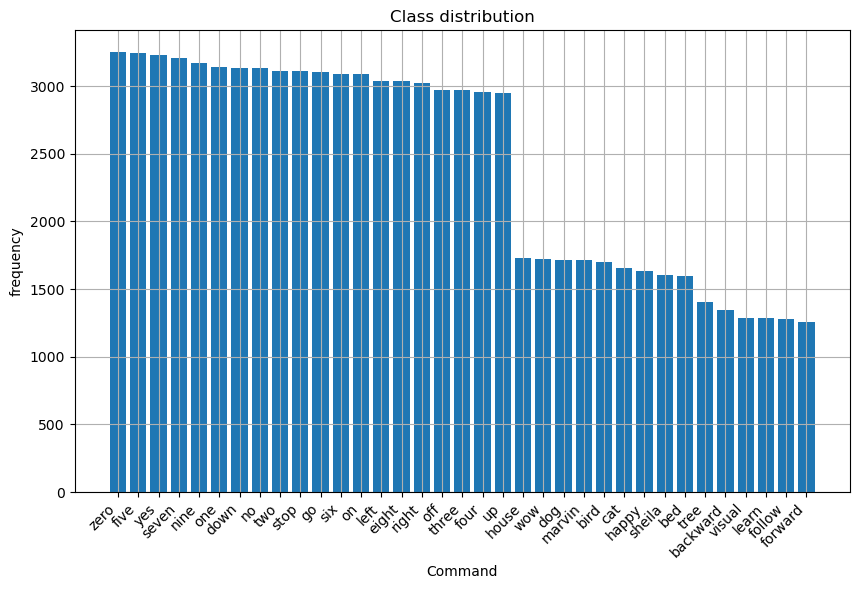

In [30]:
fig, ax = plt.subplots(figsize = (10,6))
ax.bar(value_counts['label'], value_counts['count'])
ax.set_xlabel("Command")
ax.set_ylabel('frequency')
plt.xticks(rotation=45, ha='right')
ax.set_title("Class distribution")
ax.grid()
plt.show()

In [32]:
indices = random.sample(range(len(train_set)), 5)

for i in indices:
    waveform, sample_rate, label, speaker_id, utterance_number = train_set[i]
    print(f"Label: {label} | Speaker: {speaker_id} | Utterance: {utterance_number}")
    display(Audio(waveform.numpy(), rate=sample_rate))

Label: zero | Speaker: b0f5b16d | Utterance: 2


Label: five | Speaker: 226537ab | Utterance: 2


Label: bird | Speaker: 353b4d33 | Utterance: 1


Label: nine | Speaker: 2fcb6397 | Utterance: 1


Label: left | Speaker: 779de043 | Utterance: 1
